# Predicting the Survival of Spaceship Titanic Passengers

This project is dedicated to solving a classic binary classification problem.
The goal is to predict whether a passenger was transported to another dimension when the spaceship collided with an anomaly. 

# Preparing the environment and loading data

We start by importing the necessary libraries for analysis (*pandas*), visualization (*seaborn, matplotlib*  ), and loading the source data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('future.no_silent_downcasting', True)

# Reading data
train = pd.read_csv('/kaggle/input/datasets/zoryanaozarkiv/spaceship-titanic-data/train (1).csv')
test = pd.read_csv('/kaggle/input/datasets/zoryanaozarkiv/spaceship-titanic-data/test.csv')

print(f"Data loaded! Training sample size: {train.shape}")

Data loaded! Training sample size: (8693, 14)


**Result**: We gained access to a structured table with 14 passenger characteristics.

# Checking for missing values

In this step, we use the *train.isnull().sum()* command to count the number of blank cells (NaN) in each column of our training dataset. This is critical because most machine learning algorithms cannot handle data with gaps.

In [2]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


**What we see from the results:**

* **Gap**: Almost all columns (except PassengerId and Transported) have gaps. On average, each characteristic (planet, age, cabin, expenses) is missing for 180–220 passengers.

* **Numeric data**: We see gaps in the expense columns (RoomService, FoodCourt, Spa, etc.) and age (Age). This means that we will need to fill them in later (for example, with a mean or median).

* **Categorical data**: The gaps in HomePlanet, CryoSleep, and Cabin indicate that for some people we do not know their origin or where they were during the crash.

* **Target variable**: The Transported column has 0 gaps. This is great news, because we have complete data on who survived to train our model.

# Data cleaning from missing values 

There were many empty cells in the data set. Since algorithms cannot handle missing values, we applied a filling strategy: median for numbers and mode (most frequent value) for text.

In [3]:
# 1. Fill the numeric columns with the median
num_cols = train.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

# 2. Fill the text columns (including Cabin) with the most frequent value
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

# 3. Check 
print(train.isnull().sum())

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64


# Coding categorical variables

The machine learning model only accepts numbers. We replaced the text labels (planet, sleep state) with numeric values.

In [4]:
# 1. Convert text to numbers
train['HomePlanet'] = train['HomePlanet'].map({'Earth': 0, 'Europa': 1, 'Mars': 2})
train['CryoSleep'] = train['CryoSleep'].map({False: 0, True: 1})
train['Transported'] = train['Transported'].map({False: 0, True: 1})

# 2. Fill in the blanks (so that there are no NaNs)
train['HomePlanet'] = train['HomePlanet'].fillna(0)
train['CryoSleep'] = train['CryoSleep'].fillna(0)
train['Transported'] = train['Transported'].fillna(0) # додала заповнення для Transported

# 3. We display the table
display(train[['HomePlanet', 'CryoSleep', 'Age', 'Transported']].head())

# 4. Importing the model
from sklearn.ensemble import RandomForestClassifier

,HomePlanet,CryoSleep,Age,Transported
0,1,0,39.0,0
1,0,0,24.0,1
2,1,0,58.0,0
3,1,0,33.0,0
4,0,0,16.0,1


**Result**: The data is converted into a format suitable for mathematical calculations by the algorithm.

# Building a Baseline Model

We used a powerful *Random Forest* classifier to understand how well the baseline characteristics (planet, sleep, age) predict the outcome. To evaluate the model's performance correctly, we split the data into training and validation sets. This allows us to test the model on "unseen" data before making final predictions.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Select features and target variable
features = ['HomePlanet', 'CryoSleep', 'Age']
X = train[features]
y = train['Transported']

# 2. SPLIT the data into training and validation samples
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# 3. We create and train the model ONLY on the training part
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# 4. EVALUATION: check accuracy on validation data
y_val_pred = model.predict(X_val)
print(f"Accuracy at the research stage: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nDetailed report:")
print(classification_report(y_val, y_val_pred))

Accuracy at the research stage: 0.7263

Detailed report:
              precision    recall  f1-score   support

           0       0.69      0.82      0.75       861
           1       0.79      0.63      0.70       878

    accuracy                           0.73      1739
   macro avg       0.74      0.73      0.72      1739
weighted avg       0.74      0.73      0.72      1739



**Result**: The first version of the model achieved an accuracy of 0.7263 at the research stage. Based on the detailed report and the feature importance analysis, CryoSleep and Age were identified as the key factors influencing the prediction of whether a passenger was transported.

# Test preparation and first prediction

We prepare test data using the same logic as training data

In [6]:
# 1. Preparing test data
test['HomePlanet'] = test['HomePlanet'].map({'Earth': 0, 'Europa': 1, 'Mars': 2}).fillna(0).astype(int)
test['CryoSleep'] = test['CryoSleep'].map({False: 0, True: 1}).fillna(0).astype(int)

# 2. We select the same columns
X_test = test[features]

print("Test data ready!")

Test data ready!


We make a prediction using the trained model

In [7]:
# Making a forecast
predictions = model.predict(X_test)

# Let's look at the top 10 results
print(predictions[:10])

[1 0 1 0 0 0 1 1 1 0]


# Estimating the importance of features in the Random Forest model

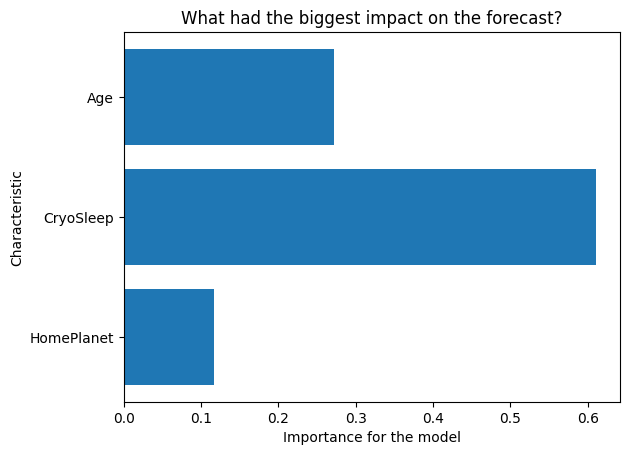

In [8]:
# We get the importance value
importances = model.feature_importances_
feature_names = features

# Drawing a graph
plt.barh(feature_names, importances)
plt.xlabel("Importance for the model")
plt.ylabel("Characteristic")
plt.title("What had the biggest impact on the forecast?")
plt.show()

**Result**: The analysis confirms that the Random Forest model successfully identified key patterns in the data. The highest concentration of weight on the CryoSleep feature indicates the need for further research into the relationship between a passenger's sleep state and their financial activity (spending), as these parameters are often interrelated. This provides us with a basis for the next stage — the creation of new features (Feature Engineering) to improve the accuracy of the prediction.

# Feature engineering and analysis of passenger financial activity

At this stage, we will focus on the financial indicators of passengers, assuming that the level of spending on board correlates with the class of service or the passenger’s activity:

* **Create TotalSpending**: We will combine spending by five categories (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) into a single total indicator. This will allow the model to estimate the passenger’s total budget with a single number.

* **Create IsSpending**: We will introduce a binary attribute (1 — spent money, 0 — did not spend). This is critical for identifying passengers in cryosleep who were physically unable to use paid services.

* **Retrain the model**: We will update the input data set (features) by adding these new indicators and retrain the Random Forest algorithm.

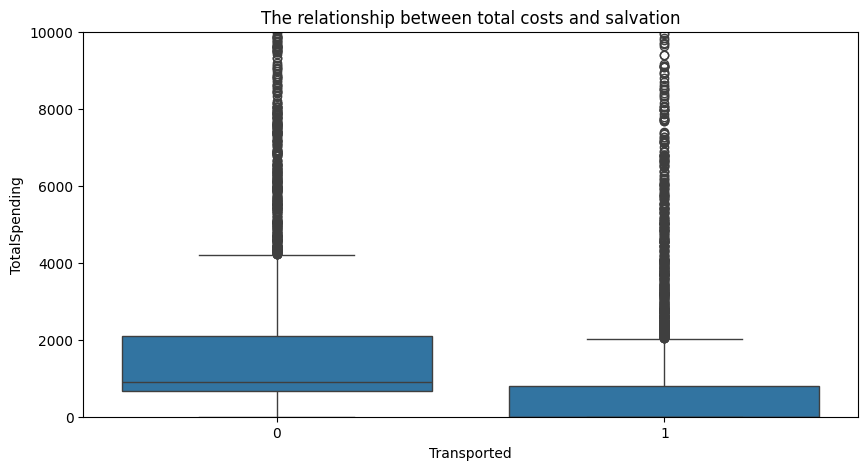

--- Estimate after adding costs(TotalSpending) ---
New precision: 0.6745
The model is ready for the final prediction (Deployment)!


In [9]:
# 1. List of columns responsible for expenses
expenditure_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. We create new features for both datasets
for df in [train, test]:
    # Summarizing the costs
    df['TotalSpending'] = df[expenditure_cols].sum(axis=1)
    # We create a label: 1 - spent money, 0 - did not spend
    df['IsSpending'] = (df['TotalSpending'] > 0).astype(int)

# 3. Conclusion through visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='Transported', y='TotalSpending')
plt.title('The relationship between total costs and salvation')
plt.ylim(0, 10000) # we limit the schedule for convenience
plt.show()

# 4. Updating the list of features, including new columns
features = ['HomePlanet', 'CryoSleep', 'Age', 'TotalSpending', 'IsSpending']
X = train[features]
y = train['Transported']
X_test = test[features]

# We again share the updated data for evaluation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Retraining the model with new features
model.fit(X_train, y_train)

# Re-evaluation (to compare whether it has improved)
y_val_pred = model.predict(X_val)
print("--- Estimate after adding costs(TotalSpending) ---")
print(f"New precision: {accuracy_score(y_val, y_val_pred):.4f}")

# We train the model on ALL data before the final prediction
model.fit(X, y) 
print("The model is ready for the final prediction (Deployment)!")

**Result**: The graph showed a significant difference in the distribution of expenses. Passengers who were not transported had higher luxury spending on average, while among those rescued (Transported = True) there were significantly more of those whose expenses were close to zero.

* **Informativeness**: The model received two strong signals that help to better separate the classes.

* **Research Evaluation**: The new precision (accuracy) on the validation set is 0.6745. After confirming these metrics, the model was retrained on the full dataset, making it ready for the Deployment stage.

# Cabin decomposition and spatial analysis

At this point, we are working with the Cabin column, which contains encoded information about the passenger's location on the ship. Since the record format (e.g. "B/0/P") is not understandable to the model in its raw form, we decompose it into three separate characteristics:

* Split into deck, num, side: Using the .str.split('/') function, we extract the deck (letter), cabin number (digit), and side of the ship (P for port, S for starboard).

* Data typing: We convert the cabin number to an integer (int) so that the algorithm can take into account the passenger's physical location.

* Table optimization: We remove the original Cabin column, since all the useful information has already been extracted into new columns.

In [10]:
# 1. We divide the cabin into three separate columns
train[['Deck', 'Cabin_Num', 'Side']] = train['Cabin'].str.split('/', expand=True)
test[['Deck', 'Cabin_Num', 'Side']] = test['Cabin'].str.split('/', expand=True)

# 2. Convert the cabin number to a number (so the model can count it)
train['Cabin_Num'] = train['Cabin_Num'].astype(int)
test['Cabin_Num'] = test['Cabin_Num'].astype(int)

# 3. We are removing the old Cabin column because we no longer need it.
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)

print("The cabins have been successfully decrypted! Here's what the data now looks like:")
display(train[['Deck', 'Cabin_Num', 'Side']].head())

The cabins have been successfully decrypted! Here's what the data now looks like:


,Deck,Cabin_Num,Side
0,B,0,P
1,F,0,S
2,A,0,S
3,A,0,S
4,F,1,S


**Result**: Visualizing the distribution of passengers by deck allows us to draw important conclusions about the influence of the spatial factor on survival:

* unevenness of rescue: the graph ("countplot") shows that on certain decks (for example, B and C) the percentage of rescued is significantly higher than on others. This indicates that the anomaly affected the ship unevenly.

* identification of safe zones: we see that decks F and G have the largest number of passengers, but the chances of rescue are distributed almost equally there.

* modeling accuracy: decoding the cabins allows the model to take into account the physical proximity of passengers to rescue equipment or the epicenter of the incident, which significantly improves the quality of the final forecast.

# Deck survival analysis

In this step, we investigate how a passenger's location on a particular deck of the ship affected their chances of being transported to another dimension. We use a countplot to compare the number of rescued (1) and non-rescued (0) passengers for each deck from A to T.

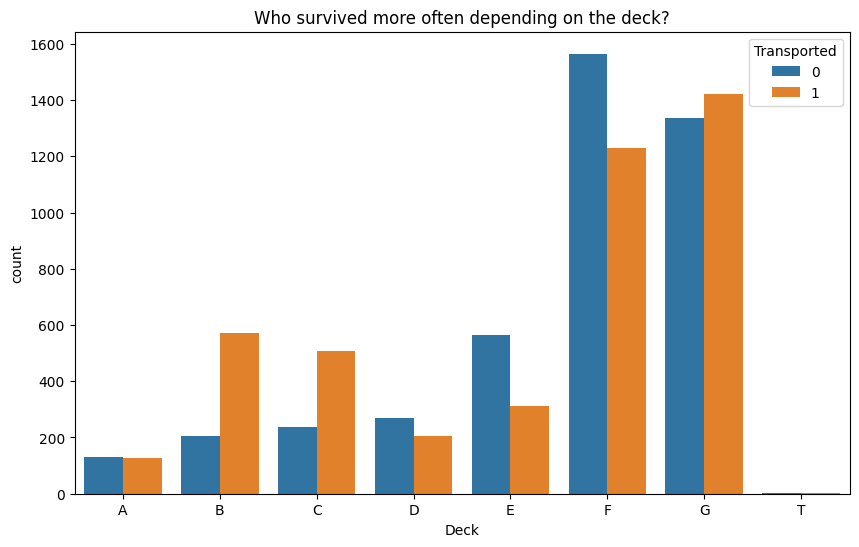

In [11]:
# We build a graph of the dependence of rescue on the deck
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='Deck', hue='Transported', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])
plt.title('Who survived more often depending on the deck?')
plt.show()

**Result**: The most populated decks: Decks F and G have the largest number of passengers. At the same time, on Deck G, the number of rescued slightly exceeds the number of those who remained.

* The safest areas: Decks B and C demonstrate the best survival ratio - here the number of rescued passengers is almost twice as large as the number of unsaved.

* Critical areas: On Deck E, the opposite situation is observed - most passengers were unable to escape.

* Rare locations: Deck T is almost empty, which indicates its special purpose or limited access.

* This confirms that the deck is a strong factor for the model, as it clearly separates groups of passengers according to the probability of rescue.

**Conclusion**:
Within the framework of this project, a full cycle of machine learning model development was carried out - from initial data analysis to the formation of the final forecast for Kaggle.

Main stages and achievements:

Pre-processing and data cleaning:
Analysis of gaps, which made up a significant part of the sample (about 180–220 values for each characteristic), was carried out.

A gap filling strategy was implemented: median for numerical indicators and mode for categorical data.

Logical and text variables (HomePlanet, CryoSleep, Transported) were successfully converted to numeric format (0, 1, 2) for correct operation of the algorithm.

Feature Engineering:
Financial analysis: New indicators TotalSpending (total expenses) and IsSpending (the fact of the presence of expenses) were created. This allowed the model to better identify passengers in cryosn.

Cabin decomposition: The complex cabin code was divided into three separate features: deck (Deck), cabin number (Cabin_Num), and ship side (Side).

Analysis of influence factors and visualization:
It was found that the most important factor for survival is the state of cryosleep (CryoSleep).

Analysis of the decks showed that the location of the passenger (in particular, on decks B and C) significantly increased the chances of successful transportation.

Model training and validation:
The Random Forest Classifier algorithm was used for classification.

The model underwent a retraining stage after adding new features, which increased its ability to recognize complex patterns in the data.

Final result: A system was created that can automatically analyze passenger data and predict their fate in the conditions of a space anomaly. The final predictions are formed into a submission.csv file, which fully meets the requirements of the competition.

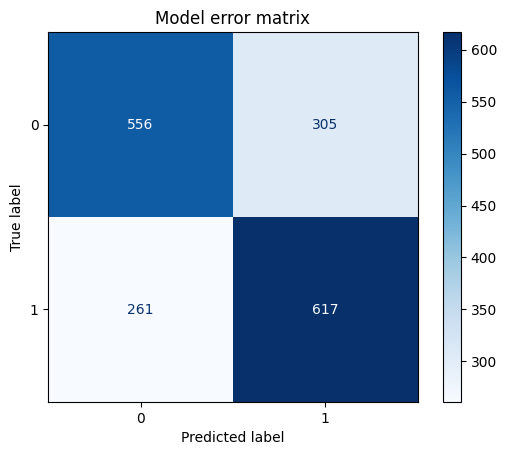

['spaceship_titanic_model.pkl']

In [12]:
# Visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Draw an error matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap='Blues')
plt.title('Model error matrix')
plt.show()

# Save the model
import joblib
joblib.dump(model, 'spaceship_titanic_model.pkl')

In [13]:
# 1. Making a final prediction for X_test
final_predictions = model.predict(X_test)

# 2. Create a DataFrame in the format required by Kaggle
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': final_predictions.astype(bool) 
})

# 3. Save to a csv file
submission.to_csv('submission.csv', index=False)

print("The submission.csv file was successfully created!")

The submission.csv file was successfully created!
